# SysML2 Execution Results Analysis

This notebook analyzes **all execution outputs currently present** under `execution_output/`, not the batch list in `batch_summary.json`.

## Metrics Covered

- Compile Success: successful execution through the SysML Jupyter kernel (`#` and `%`)
- Top failure mode
- Dominant logic error
- Distribution of error count
- Number of behavioral vs static models
- Distribution of unique errors count

In [1]:
from pathlib import Path
import json
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 140)

In [2]:
execution_dir = Path("execution_output")
diagnostics_paths = sorted(execution_dir.glob("*/*_diagnostics.json"))

print(f"Found {len(diagnostics_paths)} diagnostics files in {execution_dir}")
assert diagnostics_paths, "No diagnostics files found under execution_output/*/*_diagnostics.json"

Found 1935 diagnostics files in execution_output


In [3]:
records = []
for dp in diagnostics_paths:
    with dp.open("r", encoding="utf-8") as f:
        d = json.load(f)

    sample_id = dp.stem.replace("_diagnostics", "")
    trace_path = dp.parent / f"{sample_id}_execution_trace.txt"
    harness_path = dp.parent / f"{sample_id}_with_harness.sysml"

    records.append({
        "sample_id": sample_id,
        "diagnostics_path": str(dp),
        "output_dir": str(dp.parent),
        "trace_exists": trace_path.exists(),
        "harness_exists": harness_path.exists(),
        "compiled": bool(d.get("compiled", False)),
        "success": bool(d.get("success", False)),
        "kernel_available": d.get("kernel_available", None),
        "model_kind": d.get("model_kind", None),
        "n_errors": int(d.get("n_errors", 0)),
        "n_warnings": int(d.get("n_warnings", 0)),
        "n_unique_errors": int(d.get("n_unique_errors", 0)),
        "errors": d.get("errors", []),
        "error_counts_by_message": d.get("error_counts_by_message", {}),
        "error_counts_by_category": d.get("error_counts_by_category", {}),
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} output records")
df.head(3)

Loaded 1935 output records


,sample_id,diagnostics_path,output_dir,trace_exists,harness_exists,compiled,success,kernel_available,model_kind,n_errors,n_warnings,n_unique_errors,errors,error_counts_by_message,error_counts_by_category
0,000001,execution_output/000001/000001_diagnostics.json,execution_output/000001,True,True,True,True,True,behavioral,0,0,0,[],{},{}
1,000002,execution_output/000002/000002_diagnostics.json,execution_output/000002,True,True,True,True,True,behavioral,0,0,0,[],{},{}
2,000003,execution_output/000003/000003_diagnostics.json,execution_output/000003,True,True,True,True,True,behavioral,0,0,0,[],{},{}


In [4]:
# Compile Success through SysML Jupyter kernel
# Count as success only when kernel was available and model compiled.
compile_success_mask = df["kernel_available"].fillna(False) & df["compiled"].fillna(False)
compile_success_n = int(compile_success_mask.sum())
total_n = len(df)
compile_success_pct = (compile_success_n / total_n * 100) if total_n else 0.0

print(f"Compile Success through kernel: {compile_success_n}/{total_n} ({compile_success_pct:.2f}%)")

Compile Success through kernel: 276/1935 (14.26%)


In [5]:
# Top failure mode over all outputs present
# Prefer explicit status from diagnostics shape inferred from flags.
def infer_failure_mode(row):
    if bool(row.get("kernel_available", False)) and bool(row.get("compiled", False)):
        return "ok"
    if row.get("kernel_available", None) is False:
        return "kernel_unavailable"
    if not bool(row.get("compiled", False)):
        return "compile_failed"
    return "other_failed"

failure_mode = df.apply(infer_failure_mode, axis=1)
failure_counts = failure_mode[failure_mode != "ok"].value_counts()
print(failure_counts)

top_failure_mode = failure_counts.index[0] if not failure_counts.empty else "N/A"
top_failure_mode_count = int(failure_counts.iloc[0]) if not failure_counts.empty else 0
print()
print(f"Top failure mode: {top_failure_mode} ({top_failure_mode_count})")

compile_failed    1659
Name: count, dtype: int64

Top failure mode: compile_failed (1659)


In [6]:
# Dominant logic error (exclude parse/syntax category)
logic_error_counter = Counter()
all_error_category_counter = Counter()

for errors in df["errors"]:
    for err in errors or []:
        category = (err.get("category") or "unknown").strip().lower()
        message = (err.get("message") or "<missing message>").strip()
        all_error_category_counter[category] += 1
        if category != "parse":
            logic_error_counter[message] += 1

print("Error counts by category:")
print(pd.Series(dict(all_error_category_counter)).sort_values(ascending=False))

if logic_error_counter:
    dominant_logic_error, dominant_logic_error_count = logic_error_counter.most_common(1)[0]
    print()
    print(f"Dominant logic error: {dominant_logic_error} ({dominant_logic_error_count})")
else:
    dominant_logic_error, dominant_logic_error_count = "N/A", 0
    print()
    print("Dominant logic error: none found")

Error counts by category:
other              11202
parse               7987
feature_access       436
type_constraint      280
dtype: int64

Dominant logic error: A usage must be typed by definitions. (1304)


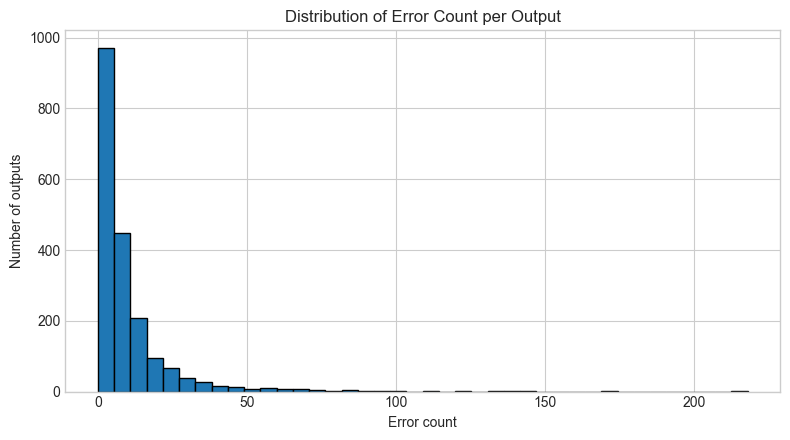

In [7]:
# Distribution of error count
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["n_errors"].fillna(0), bins=40, edgecolor="black")
ax.set_title("Distribution of Error Count per Output")
ax.set_xlabel("Error count")
ax.set_ylabel("Number of outputs")
plt.tight_layout()
plt.show()

In [8]:
# Behavioral vs static over all outputs present
model_kind_counts = df["model_kind"].fillna("unknown").value_counts()
behavioral_n = int(model_kind_counts.get("behavioral", 0))
static_n = int(model_kind_counts.get("structural", 0))
unknown_n = int(model_kind_counts.get("empty", 0) + model_kind_counts.get("unknown", 0))

print(model_kind_counts)
print()
print(f"Behavioral models: {behavioral_n}")
print(f"Static models: {static_n}")
if unknown_n:
    print(f"Other/empty/unknown: {unknown_n}")

model_kind
behavioral    1574
structural     301
empty           60
Name: count, dtype: int64

Behavioral models: 1574
Static models: 301
Other/empty/unknown: 60


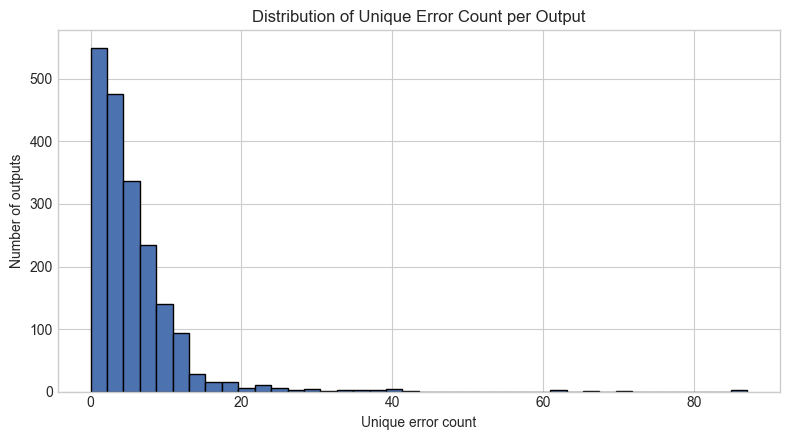

In [9]:
# Distribution of unique errors count
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["n_unique_errors"].fillna(0), bins=40, edgecolor="black", color="#4C72B0")
ax.set_title("Distribution of Unique Error Count per Output")
ax.set_xlabel("Unique error count")
ax.set_ylabel("Number of outputs")
plt.tight_layout()
plt.show()

In [10]:
summary = pd.DataFrame([
    {"metric": "Total Outputs Analyzed", "value": total_n},
    {"metric": "Compile Success (#)", "value": compile_success_n},
    {"metric": "Compile Success (%)", "value": round(compile_success_pct, 2)},
    {"metric": "Top Failure Mode", "value": top_failure_mode},
    {"metric": "Top Failure Mode Count", "value": top_failure_mode_count},
    {"metric": "Dominant Logic Error", "value": dominant_logic_error},
    {"metric": "Dominant Logic Error Count", "value": dominant_logic_error_count},
    {"metric": "Behavioral Models", "value": behavioral_n},
    {"metric": "Static Models", "value": static_n},
    {"metric": "Other/Empty/Unknown Models", "value": unknown_n},
])
summary

,metric,value
0,Total Outputs Analyzed,1935
1,Compile Success (#),276
2,Compile Success (%),14.26
3,Top Failure Mode,compile_failed
4,Top Failure Mode Count,1659
5,Dominant Logic Error,A usage must be typed by definitions.
6,Dominant Logic Error Count,1304
7,Behavioral Models,1574
8,Static Models,301
9,Other/Empty/Unknown Models,60
